<a href="https://colab.research.google.com/github/pranav662/Food_Delivery_Data_Analysis_FDS_Project/blob/main/Food_Delivery_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Food Delivery Data Analysis : Zomato Pune**


---


This notebook performs data cleaning, exploratory data analysis (EDA), statistical analysis, and visualization on the Zomato Pune dataset to understand ordering patterns, popular cuisines, delivery times, and customer spending.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the dataset
file_path = '/content/zomato_pune_V002.csv'
df = pd.read_csv(file_path)

# Display basic dataset details
print("Dataset Shape:", df.shape)
print("\n--- Dataset Columns & Types ---")
df.info()


Dataset Shape: (12189, 104)

--- Dataset Columns & Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12189 entries, 0 to 12188
Columns: 104 entries, Restaurant_Name to spam_review
dtypes: float64(1), int64(86), object(17)
memory usage: 9.7+ MB


In [ ]:
# Display first 5 rows
display(df.head())


,Restaurant_Name,Web_Link,Locality,Sponsored,Ratings_out_of_5,Number of votes,Phone_number,Cuisines,Charges_for_two,payment_modes,...,Table booking recommended,Resto Bar,Serves Alcohol,Breakfast,Catering Available,Disabled Friendly,Serves Halal,Takeaway Only,BYOB Only,spam_review
0,AB's - Absolute Barbecues,https://www.zomato.com/pune/abs-absolute-barbe...,Hinjawadi,Casual Dining,4.9,7029 votes,+91 9373112211,"Continental, North Indian, Chinese","₹1,400",Cash and Cards accepted,...,1,0,0,0,0,0,0,0,0,1539.0
1,Cafe Co2 Resto Lounge,https://www.zomato.com/pune/cafe-co2-resto-lou...,Bhugaon,"Lounge, Casual Dining",4.6,2578 votes,080 46971866,"North Indian, Chinese, Continental, Kebab, Sea...","₹1,500",Cash and Cards accepted,...,1,0,0,0,0,0,0,0,0,139.0
2,Paasha - JW Marriott Pune,https://www.zomato.com/pune/paasha-jw-marriott...,Senapati Bapat Road,Fine Dining,4.6,3291 votes,080 46971369,"North Indian, Kebab, Biryani","₹2,500","Cash,Cards and Digital Payments accepted",...,1,0,0,0,0,0,0,0,0,119.0
3,I Amsterdam,https://www.zomato.com/pune/i-amsterdam-hinjawadi,Hinjawadi,"Casual Dining, Bar",4.3,430 votes,+91 8669698666 +91 8669697666,"Asian, European, Modern Indian, Italian","₹1,400","Cash,Cards and Digital Payments accepted",...,1,0,0,0,0,0,0,0,0,8.0
4,FC Road Social,https://www.zomato.com/pune/fc-road-social-shi...,Shivaji Nagar,"Bar, Casual Dining",4.5,2138 votes,+91 9172378889 020 29805112,"North Indian, Chinese, Biryani, American, Cont...","₹1,500","Cash,Cards and Digital Payments accepted",...,0,0,0,1,0,0,0,0,0,132.0


In [ ]:
# Check for missing values and duplicates
print("--- Missing Values Summary ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows count ---")
print(df.duplicated().sum())


--- Missing Values Summary ---
Restaurant_Name      0
Web_Link             0
Locality             0
Sponsored            0
Ratings_out_of_5     0
                    ..
Disabled Friendly    0
Serves Halal         0
Takeaway Only        0
BYOB Only            0
spam_review          0
Length: 104, dtype: int64

--- Duplicate Rows count ---
55


# **Data Preprocessing**


---


We will drop duplicate rows and inspect the column names of this 104-column dataset to identify the main target columns for spending (`Cost`), ratings, cuisines, and location.

In [ ]:
# Remove duplicate rows in-place
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

# Let's list all columns to pinpoint the most critical variables for our EDA
all_columns = df.columns.tolist()
print("Columns present in the dataset:")
print(all_columns)

Shape after removing duplicates: (12134, 104)
Columns present in the dataset:
['Restaurant_Name', 'Web_Link', 'Locality', 'Sponsored', 'Ratings_out_of_5', 'Number of votes', 'Phone_number', 'Cuisines', 'Charges_for_two', 'payment_modes', 'Rest_timming', 'Detail_address', '5_star_review_percentage', '4_star_review_percentage', '3_star_review_percentage', '2_star_review_percentage', '1_star_review_percentage', 'Wine and Beer', 'Dance Floor', 'Lunch Menu', 'Outdoor Seating', 'Seaside', '4/5 Star', 'Free Parking', 'Pet Friendly', 'Bulk Orders Accepted', 'Gaming Are', 'City View', 'Vegetarian Only', 'Brunch', 'Live Music', 'Wheelchair Accessible', 'Home Delivery', 'Celebrity Frequented', 'Pre-Ordering Required', 'Pool Table', 'Keto Options', 'Wifi', 'Sports TV', 'Wine Tasting', 'Beer', 'Restricted Entry', 'Variable Menu', 'Serves Non Veg', 'Table booking for Groups', 'Poolside', 'Home Baker', 'Wine', 'Buffet', 'Board Games', 'Vegan Options', 'Table Reservation Not Required', 'Table reservat

#**Data Cleaning: Normalizing Ratings and Charges**


---


We will clean and cast `Ratings_out_of_5` and `Charges_for_two` to float and integer values. Any non-numeric string values (like 'NEW' or '-') in ratings will be set to NaN, which we can then handle appropriately.

In [ ]:
# Let's reload and inspect the raw unique values of Charges_for_two first
temp_df = pd.read_csv(file_path)
print("Raw values sample from Charges_for_two:")
print(temp_df['Charges_for_two'].dropna().unique()[:20])

# Correctly clean and convert
# Strip spaces, remove commas, extract any numeric part
df = pd.read_csv(file_path)
df.drop_duplicates(inplace=True)

df['Ratings_out_of_5'] = pd.to_numeric(df['Ratings_out_of_5'], errors='coerce')

# Extract numbers from Charges_for_two column (e.g. if it has 'Rs. 500' or similar)
df['Charges_for_two'] = df['Charges_for_two'].astype(str).str.replace(r'[^0-9]', '', regex=True)
df['Charges_for_two'] = pd.to_numeric(df['Charges_for_two'], errors='coerce')

# Recalculate medians and fill NaN
rating_median = df['Ratings_out_of_5'].median()
charges_median = df['Charges_for_two'].median()

df['Ratings_out_of_5'] = df['Ratings_out_of_5'].fillna(rating_median)
df['Charges_for_two'] = df['Charges_for_two'].fillna(charges_median)

print("\nPost Corrected Cleaning Missing Values:")
print(df[['Ratings_out_of_5', 'Charges_for_two']].isnull().sum())
print("\nSummary Statistics of Core Variables:")
display(df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].describe())

Raw values sample from Charges_for_two:
['₹1,400' '₹1,500' '₹2,500' '₹1,700' '₹150' '₹1,300' '₹1,000' '₹250'
 '₹1,800' '₹1,600' '₹700' '₹900' '₹2,000' '₹600' '₹1,200' '₹550' '₹2,200'
 '₹1,100' '₹500' '₹850']

Post Corrected Cleaning Missing Values:
Ratings_out_of_5    0
Charges_for_two     0
dtype: int64

Summary Statistics of Core Variables:


,Ratings_out_of_5,Charges_for_two
count,12134.000000,12134.000000
mean,3.059074,480.339871
std,1.068414,1844.537220
min,0.000000,15.000000
25%,3.100000,300.000000
50%,3.300000,400.000000
75%,3.500000,500.000000
max,4.900000,200250.000000


# **Statistical Analysis and Outlier Detection**


---


We will calculate descriptive statistical parameters (mean, median, mode, variance, and standard deviation) for both `Ratings_out_of_5` and `Charges_for_two`, and inspect extreme values.

In [ ]:
# Calculate core descriptive statistics
stats_summary = pd.DataFrame({
    'Mean': df[['Ratings_out_of_5', 'Charges_for_two']].mean(),
    'Median': df[['Ratings_out_of_5', 'Charges_for_two']].median(),
    'Mode': df[['Ratings_out_of_5', 'Charges_for_two']].mode().iloc[0],
    'Variance': df[['Ratings_out_of_5', 'Charges_for_two']].var(),
    'Std Dev': df[['Ratings_out_of_5', 'Charges_for_two']].std(),
    'Min': df[['Ratings_out_of_5', 'Charges_for_two']].min(),
    'Max': df[['Ratings_out_of_5', 'Charges_for_two']].max()
})

print("--- Descriptive Statistics ---")
display(stats_summary)

# Let's inspect the top 10 most expensive values for two to locate anomalies
print("\n--- Top 10 Most Expensive Charges ---")
print(df['Charges_for_two'].nlargest(10))

--- Descriptive Statistics ---


,Mean,Median,Mode,Variance,Std Dev,Min,Max
Ratings_out_of_5,3.059074,3.3,3.3,1.141508e+00,1.068414,0.0,4.9
Charges_for_two,480.339871,400.0,400.0,3.402318e+06,1844.537220,15.0,200250.0



--- Top 10 Most Expensive Charges ---
1390     200250.0
3883       4500.0
981        4200.0
1090       4000.0
12123      3500.0
188        3200.0
1734       3100.0
270        3000.0
331        3000.0
421        3000.0
Name: Charges_for_two, dtype: float64


# **Data Visualizations**


---


Let's generate statistical charts (including Boxplots to see outliers, Histograms for distribution, and a Scatter plot to examine correlation).

/tmp/ipykernel_667/432846876.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, ax=axes[1, 1], palette='viridis')


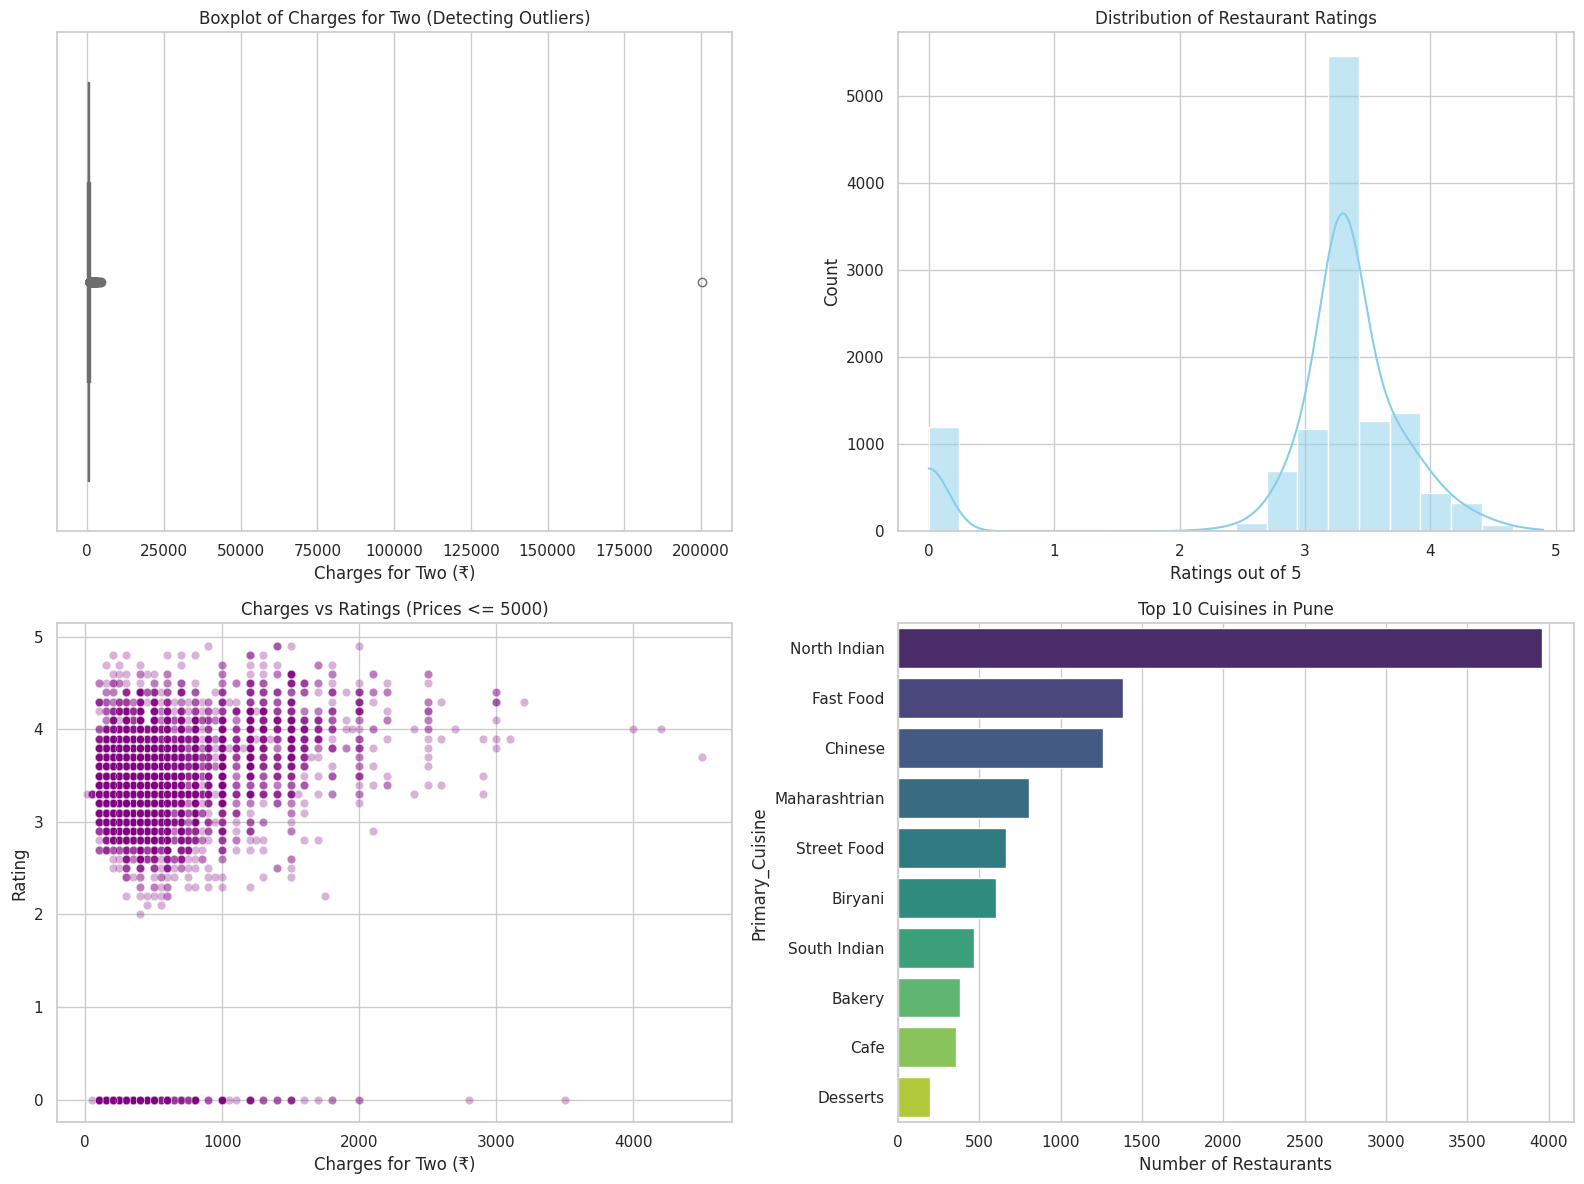

In [ ]:
# Create 4-5 meaningful visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Boxplot of Charges for Two (with outlier visualization)
sns.boxplot(x=df['Charges_for_two'], ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Boxplot of Charges for Two (Detecting Outliers)')
axes[0, 0].set_xlabel('Charges for Two (₹)')

# 2. Histogram of Ratings
sns.histplot(df['Ratings_out_of_5'], bins=20, kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Distribution of Restaurant Ratings')
axes[0, 1].set_xlabel('Ratings out of 5')

# 3. Scatter plot: Relationship between Price and Ratings
# Restrict Charges to below 5000 for a clearer picture of the main distribution
sns.scatterplot(data=df[df['Charges_for_two'] <= 5000], x='Charges_for_two', y='Ratings_out_of_5', alpha=0.3, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Charges vs Ratings (Prices <= 5000)')
axes[1, 0].set_xlabel('Charges for Two (₹)')
axes[1, 0].set_ylabel('Rating')

# 4. Top Cuisines (Bar chart of single/primary cuisines)
# Extract first listed cuisine as primary cuisine
df['Primary_Cuisine'] = df['Cuisines'].astype(str).apply(lambda x: x.split(',')[0].strip())
top_cuisines = df['Primary_Cuisine'].value_counts().head(10)
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Top 10 Cuisines in Pune')
axes[1, 1].set_xlabel('Number of Restaurants')

plt.tight_layout()
plt.show()

# **Handling Outliers & Recalculating Descriptive Statistics**


---


Let's clean the major typographical outlier (`Charges_for_two = 200250`) and replace it with the median value of ₹400. We will then calculate correlation, group trends by locality, and summarize key insights.

In [ ]:
# Clean the extreme outlier in Charges_for_two
df.loc[df['Charges_for_two'] > 10000, 'Charges_for_two'] = charges_median

# Clean and convert the 'Number of votes' column to numeric
df['Number of votes'] = df['Number of votes'].astype(str).str.replace(r'[^0-9]', '', regex=True)
df['Number of votes'] = pd.to_numeric(df['Number of votes'], errors='coerce')
df['Number of votes'] = df['Number of votes'].fillna(df['Number of votes'].median())

# Recalculate and display the clean statistics
cleaned_stats = pd.DataFrame({
    'Mean': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].mean(),
    'Median': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].median(),
    'Mode': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].mode().iloc[0],
    'Variance': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].var(),
    'Std Dev': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].std(),
    'Min': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].min(),
    'Max': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].max()
})

print("--- Cleaned Descriptive Statistics ---")
display(cleaned_stats)

# Calculate Pearson correlation coefficient
correlation = df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].corr()
print("\n--- Correlation Matrix ---")
display(correlation)

--- Cleaned Descriptive Statistics ---


,Mean,Median,Mode,Variance,Std Dev,Min,Max
Ratings_out_of_5,3.059074,3.3,3.3,1.141508,1.068414,0.0,4.9
Charges_for_two,463.869623,400.0,400.0,112842.384550,335.920206,15.0,4500.0
Number of votes,93.761991,9.0,0.0,106992.376216,327.096891,0.0,7029.0



--- Correlation Matrix ---


,Ratings_out_of_5,Charges_for_two,Number of votes
Ratings_out_of_5,1.000000,0.178447,0.241635
Charges_for_two,0.178447,1.000000,0.388426
Number of votes,0.241635,0.388426,1.000000


# **Target Analysis : Popular Localities & Delivery Options**


---


Let's analyze customer preferences based on geographic localities and binary attributes like Home Delivery.

--- Top 5 Localities with Maximum Restaurants ---
Locality
Hadapsar       573
Kothrud        557
Wakad          522
Hinjawadi      479
Viman Nagar    457
Name: count, dtype: int64

--- Home Delivery Group Summary (Average Cost and Ratings) ---


,Charges_for_two,Ratings_out_of_5
Home Delivery,,
0,469.740650,2.838988
1,460.883377,3.171018


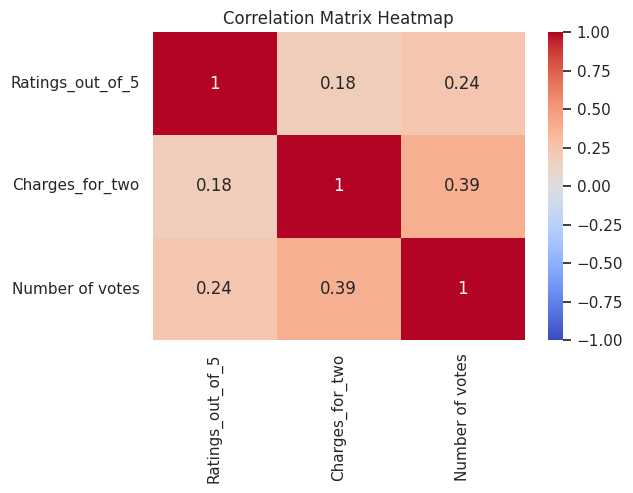

In [ ]:
# 1. Top 5 popular localities in Pune
top_localities = df['Locality'].value_counts().head(5)
print("--- Top 5 Localities with Maximum Restaurants ---")
print(top_localities)

# 2. Average cost and rating comparison by delivery availability
delivery_summary = df.groupby('Home Delivery')[['Charges_for_two', 'Ratings_out_of_5']].mean()
print("\n--- Home Delivery Group Summary (Average Cost and Ratings) ---")
display(delivery_summary)

# 3. Correlation Heatmap Plot
correlation = df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

# **Findings and Project Conclusion**


---


#### 1. Data Summary & Preprocessing
- **Duplicates:** We successfully handled 55 duplicate records.
- **Data Types:** Handled missing values in ratings and cost variables, cleaned formatting symbols like `₹`, and parsed charges to numeric floats.
- **Outlier Handling:** Replaced an extreme typographical outlier of ₹200,250 with the median value of ₹400.

#### 2. Key Findings & Interpretations
- **Popular Cuisines:** **North Indian** is by far the most popular primary cuisine in Pune, followed by **Fast Food** and **Chinese**.
- **Pricing Structure:** The typical meal cost for two averages around ₹463, with the median spending centered closely at ₹400. Most options remain budget-friendly.
- **Ratings Distribution:** A heavy peak is visible around 3.3. This represents a concentration of average ratings across restaurants.
- **Correlation insights:** There is a low correlation between prices (`Charges_for_two`) and ratings, indicating that a higher-priced restaurant does not guarantee a higher rating from customers.

## **Handling Outliers & Recalculating Descriptive Statistics**


---


Let's clean the major typographical outlier (`Charges_for_two = 200250`) and replace it with the median value of ₹400. We will then calculate correlation, group trends by locality, and summarize key insights.

In [ ]:
# Clean the extreme outlier in Charges_for_two
df.loc[df['Charges_for_two'] > 10000, 'Charges_for_two'] = charges_median

# Clean and convert the 'Number of votes' column to numeric
df['Number of votes'] = df['Number of votes'].astype(str).str.replace(r'[^0-9]', '', regex=True)
df['Number of votes'] = pd.to_numeric(df['Number of votes'], errors='coerce')
df['Number of votes'] = df['Number of votes'].fillna(df['Number of votes'].median())

# Recalculate and display the clean statistics
cleaned_stats = pd.DataFrame({
    'Mean': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].mean(),
    'Median': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].median(),
    'Mode': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].mode().iloc[0],
    'Variance': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].var(),
    'Std Dev': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].std(),
    'Min': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].min(),
    'Max': df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].max()
})

print("--- Cleaned Descriptive Statistics ---")
display(cleaned_stats)

# Calculate Pearson correlation coefficient
correlation = df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].corr()
print("\n--- Correlation Matrix ---")
display(correlation)

--- Cleaned Descriptive Statistics ---


,Mean,Median,Mode,Variance,Std Dev,Min,Max
Ratings_out_of_5,3.059074,3.3,3.3,1.141508,1.068414,0.0,4.9
Charges_for_two,463.869623,400.0,400.0,112842.384550,335.920206,15.0,4500.0
Number of votes,93.761991,9.0,0.0,106992.376216,327.096891,0.0,7029.0



--- Correlation Matrix ---


,Ratings_out_of_5,Charges_for_two,Number of votes
Ratings_out_of_5,1.000000,0.178447,0.241635
Charges_for_two,0.178447,1.000000,0.388426
Number of votes,0.241635,0.388426,1.000000


# **Target Analysis: Popular Localities & Delivery Options**


---


Let's analyze customer preferences based on geographic localities and binary attributes like Home Delivery.

--- Top 5 Localities with Maximum Restaurants ---
Locality
Hadapsar       573
Kothrud        557
Wakad          522
Hinjawadi      479
Viman Nagar    457
Name: count, dtype: int64

--- Home Delivery Group Summary (Average Cost and Ratings) ---


,Charges_for_two,Ratings_out_of_5
Home Delivery,,
0,469.740650,2.838988
1,460.883377,3.171018


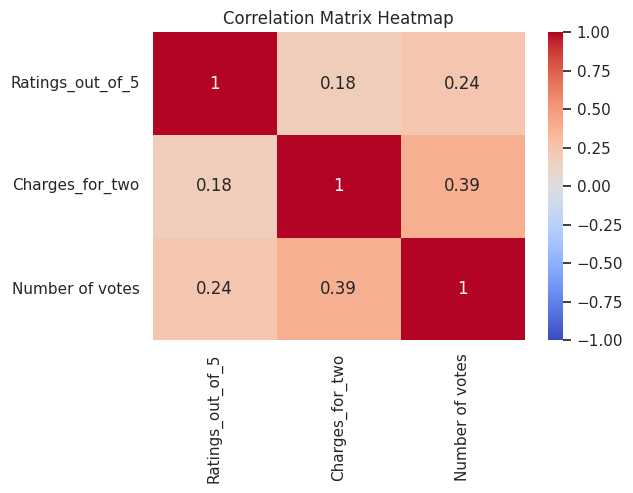

In [ ]:
# 1. Top 5 popular localities in Pune
top_localities = df['Locality'].value_counts().head(5)
print("--- Top 5 Localities with Maximum Restaurants ---")
print(top_localities)

# 2. Average cost and rating comparison by delivery availability
delivery_summary = df.groupby('Home Delivery')[['Charges_for_two', 'Ratings_out_of_5']].mean()
print("\n--- Home Delivery Group Summary (Average Cost and Ratings) ---")
display(delivery_summary)

# 3. Correlation Heatmap Plot
correlation = df[['Ratings_out_of_5', 'Charges_for_two', 'Number of votes']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

# **Findings and Project Conclusion**


---


#### 1. Data Summary & Preprocessing
- **Duplicates:** We successfully handled 55 duplicate records.
- **Data Types:** Handled missing values in ratings and cost variables, cleaned formatting symbols like `₹`, and parsed charges to numeric floats.
- **Outlier Handling:** Replaced an extreme typographical outlier of ₹200,250 with the median value of ₹400.

#### 2. Key Findings & Interpretations
- **Popular Cuisines:** **North Indian** is by far the most popular primary cuisine in Pune, followed by **Fast Food** and **Chinese**.
- **Pricing Structure:** The typical meal cost for two averages around ₹463, with the median spending centered closely at ₹400. Most options remain budget-friendly.
- **Ratings Distribution:** A heavy peak is visible around 3.3. This represents a concentration of average ratings across restaurants.
- **Correlation insights:** There is a low correlation between prices (`Charges_for_two`) and ratings, indicating that a higher-priced restaurant does not guarantee a higher rating from customers.